# Classical Kalman filter baseline

The Kalman filter serves as an intuitive baseline for KIND. As KIND is Kalman-inspired, we analyze how the Kalman filter behaves when confronted with unmodeled or misspecified dynamics.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/kalman'
model_dir = '../../models/kalman'
result_dir = '../../results/kalman'

# --! import Python libraries --!

import numpy as np
import torch
import pandas as pd

import example_kalman
import util_data

## Design a Kalman filter

To establish a physics-based reference, we designed a classical Kalman filter using the nominal detuning dynamics of the cavity. The mechanical subsystem was represented by three dominant modes at 10 Hz, 40 Hz, and 100 Hz, identified from the stationary portion of the measured data.

In [2]:
dt = 0.001

param_track = {
    'f'  :   np.array([100., 40., 10.]),
    'q'  :   np.array([1000., 400., 100.]),
    'k'  :   np.array([-1.0, 1.0, -0.1]),
    'dt' :   dt,
    'kalman_q' : 1.0,
    'kalman_r' : 0.1,
}

kf_track = example_kalman.filter_detuning(param_track)
c = example_kalman.make_mm_c_array(len(param_track['f']))

param_model = {
    'f'  :   np.array([100., 40., 10.]),
    'q'  :   np.array([1000., 400., 100.]),
    'k'  :   np.array([-1.0, 1.0, -0.1]),
    'dt' :   dt,
    'kalman_q' : 0.1,
    'kalman_r' : 1.0,
}

kf_model = example_kalman.filter_detuning(param_model)

param_divergence = {
    'f'  :   np.array([100., 40., 10.]),
    'q'  :   np.array([1000., 400., 100.]),
    'k'  :   np.array([-1.0, -1.0, -0.1]),
    'dt' :   dt,
    'kalman_q' : 0.1,
    'kalman_r' : 1.0,
}

kf_divergence = example_kalman.filter_detuning(param_divergence)

## Load detuning trajectory data

In [3]:
data_path = f'{data_dir}/eval.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
traj_true = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy().copy()), 0)

print(f'inf > loaded true trajectory with shape: {traj_true.shape}')

inf > loaded true trajectory with shape: torch.Size([1, 1000, 1])


## Evaluate a Kalman filter

A Kalman filter is sensitive to the choice of $Q$ and $R$ parameters. When $Q=1.0$ and $R=0.1$, the filter relies heavily on data and thus performs good tracking. When $Q=0.1$ and $R=1.0$, the filter overestimates its model. Even though the model is based on the three most dominant modes, these modes are still affected by other, less-pronounced modes. When a coupling sign changes, the filter diverges.

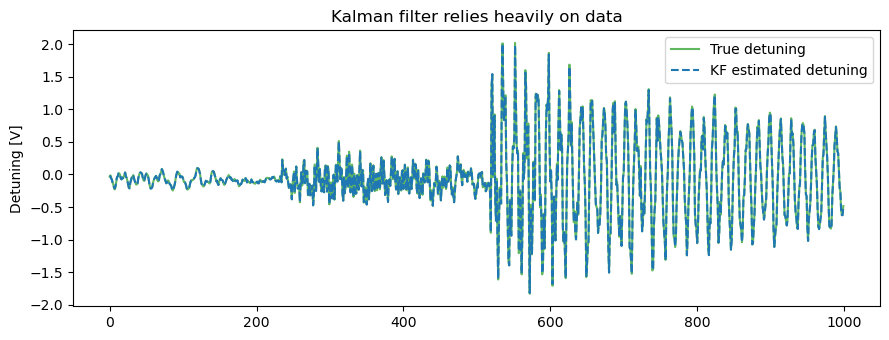

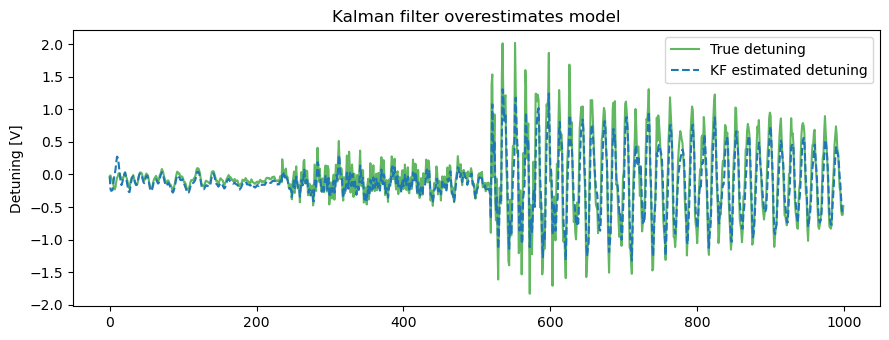

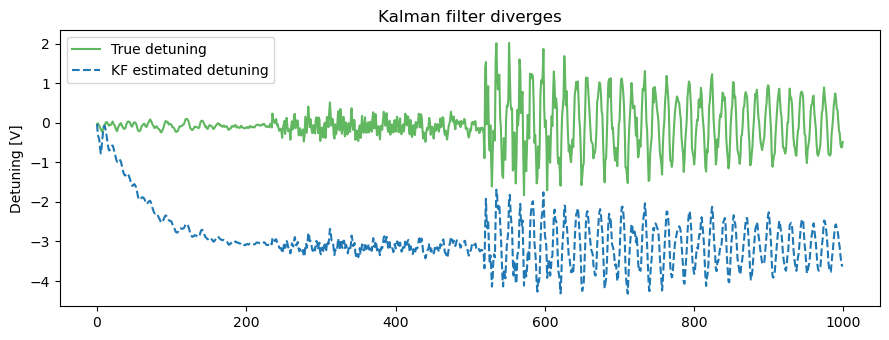

In [4]:
grad = 9.5 * 0.1615
u = np.array([[np.square(grad)]])
data = traj_true[0]

detuning_est = example_kalman.rollout_kf(kf_track, c, data, u)
example_kalman.plot_kf(data, detuning_est, 'Kalman filter relies heavily on data')

detuning_est = example_kalman.rollout_kf(kf_model, c, data, u)
example_kalman.plot_kf(data, detuning_est, 'Kalman filter overestimates model')

detuning_est = example_kalman.rollout_kf(kf_divergence, c, data, u)
example_kalman.plot_kf(data, detuning_est, 'Kalman filter diverges')

datasaved = False
if datasaved:
    step = np.arange(data.shape[0]).reshape(-1, 1)
    savedata = np.expand_dims(
        np.concatenate(
            [step[:, [0]], data[:, [0]], detuning_est[:, [0]]], axis=1), 0)
    util_data.write_datafile(
        f'{result_dir}/kalman_q_{param_track['kalman_q']}_r_{param_track['kalman_r']}_k_{param_track['k'][1]}',
        savedata,
        delim=' ')